# Setting up


**Importing Libraries**



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings("ignore")

**Reading Data**

In [3]:
df = pd.read_csv("train.csv")

**Data Information**

In [4]:
df.shape

(100000, 28)

In [5]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [7]:
df.head(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


In [8]:
df.describe(exclude=np.number)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,100000,88592,92998,100000,100000,100000,90970,100000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,434,6260,749,4384,4,13178,404,3,91049,7,98792,3
top,0x25fd5,CUS_0x942c,January,Stevex,38,#F%$D@*&8,_______,36585.12,3,Not Specified,19,_,Standard,1360.45,15 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,14386,1408,5327,2091,36479,24,446,52326,4305,25513,9,53174


In [9]:
df=df.drop(['ID','Name','SSN','Customer_ID'],axis=1)

In [10]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


# Data cleaning

Check Duplicates Rows

In [11]:
df.duplicated().sum()

np.int64(0)

Missing Data- NULL Values

In [12]:
df.isnull().sum().sort_values(ascending = False)

,0
Monthly_Inhand_Salary,15002
Type_of_Loan,11408
Credit_History_Age,9030
Num_of_Delayed_Payment,7002
Amount_invested_monthly,4479
Num_Credit_Inquiries,1965
Monthly_Balance,1200
Month,0
Interest_Rate,0
Num_Credit_Card,0


In [13]:
# Fix Age in data
df['Age'] = df['Age'].apply(lambda x: np.nan if "_" in x else int(x))
df["Age"] = df["Age"].fillna(df["Age"].ffill())
df['Age'].isnull().sum()

np.int64(0)

In [14]:
# Credit history age in months (parse safely to avoid errors on "NA" or malformed strings)
df = df[df['Credit_History_Age'].notna()]
def parse_credit_history_age(s):
    try:
        parts = str(s).split()
        if len(parts) >= 5 and parts[1] == 'Years' and parts[4] == 'Months':
            return int(parts[0]) * 12 + int(parts[3])
    except (ValueError, IndexError):
        pass
    return np.nan
df['Credit_History_Age'] = df['Credit_History_Age'].apply(parse_credit_history_age)
df = df[df['Credit_History_Age'].notna()]  # drop rows that could not be parsed
df['Credit_History_Age'].isnull().sum()

np.int64(0)

In [15]:
# Fix Annual Income in data
df['Annual_Income'] = df['Annual_Income'].apply(lambda x: float(str(x).replace("_","")) if "_" in x else float(x))

In [16]:
# Delay_from_due_date should not be negative
df['Delay_from_due_date'] = df['Delay_from_due_date'].apply(lambda x: abs(x))

In [17]:
# Fill NA values in Monthly inhand salary
df['Monthly_Inhand_Salary']=df['Monthly_Inhand_Salary'].fillna(df['Annual_Income']/12)
df['Monthly_Inhand_Salary'].isnull().sum()

np.int64(0)

In [18]:
# Fix Amount_invested_monthly in data
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].apply(lambda x: np.nan if x=="__10000__" or x=="" else float(x))
mean_value=df['Amount_invested_monthly'].mean()
df['Amount_invested_monthly'].fillna(value=mean_value, inplace=True)
# Changed Null value to Mean..!!
df['Amount_invested_monthly'].isnull().sum()

np.int64(0)

In [19]:
# Fix monthly balance in data
df['Monthly_Balance'] = df['Monthly_Balance'].apply(lambda x: np.nan if x=="__-333333333333333333333333333__" or x=="" else float(x))
mean_value1=df['Monthly_Balance'].mean()
df['Monthly_Balance'].fillna(value=mean_value1, inplace=True)
#Changed Null values to Mean ..!!

df['Monthly_Balance'].isnull().sum()

np.int64(0)

In [20]:
df['Outstanding_Debt']=df['Outstanding_Debt'].apply(lambda x: float(str(x).replace("_","")) if "_" in x else float(x))

In [21]:
df.Credit_Mix.value_counts()

,count
Credit_Mix,
Standard,33161
Good,22151
_,18371
Bad,17287


In [22]:
# cleaning credit mix
df['Credit_Mix'] = df['Credit_Mix'].apply(lambda x: np.nan if x=="_" or x=="" else x)
df['Credit_Mix'] = df['Credit_Mix'].ffill()  # ffill() replaces deprecated fillna(method='pad')

In [23]:
df.Payment_Behaviour.value_counts()

,count
Payment_Behaviour,
Low_spent_Small_value_payments,23181
High_spent_Medium_value_payments,15965
Low_spent_Medium_value_payments,12620
High_spent_Large_value_payments,12505
High_spent_Small_value_payments,10308
Low_spent_Large_value_payments,9480
!@9#%8,6911


In [24]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].apply(lambda x: "Unknown" if x=="!@9#%8" else x)

In [25]:
df['Payment_of_Min_Amount']=df['Payment_of_Min_Amount'].apply(lambda x: "No" if x=="NM" or x=="" else x)

In [26]:
# Fill missing values with 0 in Num_Credit_Inquiries
df['Num_Credit_Inquiries']=df['Num_Credit_Inquiries'].fillna(0)

In [27]:
# cleaning num of delayed payment
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna("0")
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].apply(lambda x: str(str(x).replace("_","")))
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].apply(lambda x: abs(float(x)))

In [28]:
# filling not specified instead of na
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Not Specified')

In [29]:
# cleaning Changed Credit limit
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].apply(lambda x: str(str(x).replace("_","0")))
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].apply(lambda x: (float(x)))

In [30]:
# Num_of_Loan (safe parsing: empty string after replace would cause float() to fail)
def safe_num_of_loan(x):
    s = str(x).replace("_", "").strip()
    if not s:
        return np.nan
    try:
        return abs(float(s))
    except ValueError:
        return np.nan
df['Num_of_Loan'] = df['Num_of_Loan'].apply(safe_num_of_loan)
df['Num_of_Loan'] = df['Num_of_Loan'].fillna(df['Num_of_Loan'].median())

# EDA

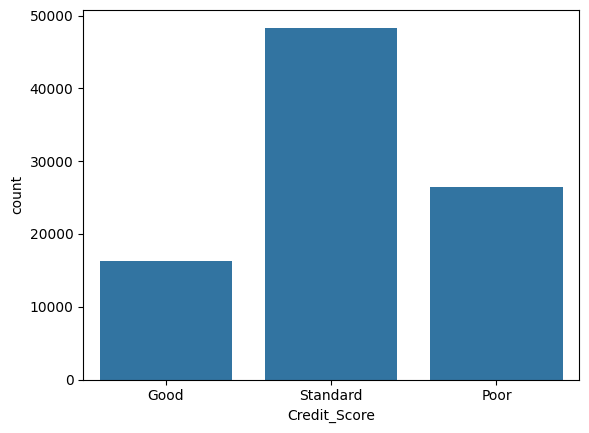

In [31]:
sns.countplot(x='Credit_Score',data=df)
plt.show()

<Axes: ylabel='Changed_Credit_Limit'>

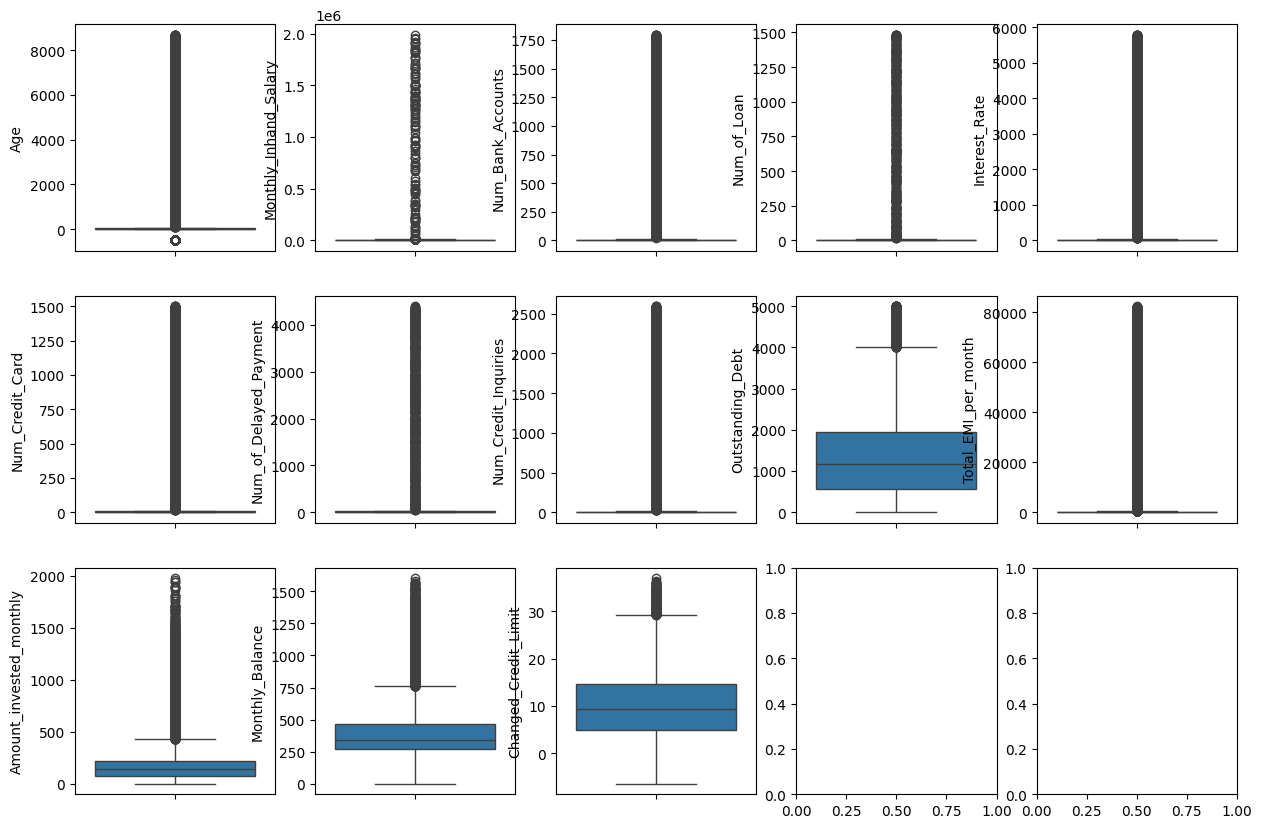

In [32]:
#make boxplots of each numeric variable to see if there are any outliers and plot them in same row
fig, ax = plt.subplots(3, 5, figsize=(15, 10))
sns.boxplot(y=df['Age'], ax=ax[0, 0])
sns.boxplot(y=df['Monthly_Inhand_Salary'], ax=ax[0, 1])
sns.boxplot(y=df['Num_Bank_Accounts'], ax=ax[0, 2])
sns.boxplot(y=df['Num_of_Loan'], ax=ax[0, 3])
sns.boxplot(y=df['Interest_Rate'], ax=ax[0, 4])
sns.boxplot(y=df['Num_Credit_Card'], ax=ax[1, 0])
sns.boxplot(y=df['Num_of_Delayed_Payment'], ax=ax[1, 1])
sns.boxplot(y=df['Num_Credit_Inquiries'], ax=ax[1, 2])
sns.boxplot(y=df['Outstanding_Debt'], ax=ax[1, 3])
sns.boxplot(y=df['Total_EMI_per_month'], ax=ax[1, 4])
sns.boxplot(y=df['Amount_invested_monthly'], ax=ax[2, 0])
sns.boxplot(y=df['Monthly_Balance'], ax=ax[2, 1])
sns.boxplot(y=df['Changed_Credit_Limit'], ax=ax[2, 2])

In [33]:
# removing huge outliers and creating box plot again to see finer outliers
df = df[(df['Age'] <= 100)]
df = df[(df['Age'] >= 0)]
df = df[(df['Num_Bank_Accounts'] <= 200)]
df = df[(df['Num_of_Loan'] < 150)]
df = df[(df['Interest_Rate'] < 150)]
df = df[(df['Num_of_Delayed_Payment'] < 100)]
df = df[(df['Num_Credit_Inquiries'] <100)]
df = df[(df['Num_Credit_Card'] <100)]


<Axes: ylabel='Changed_Credit_Limit'>

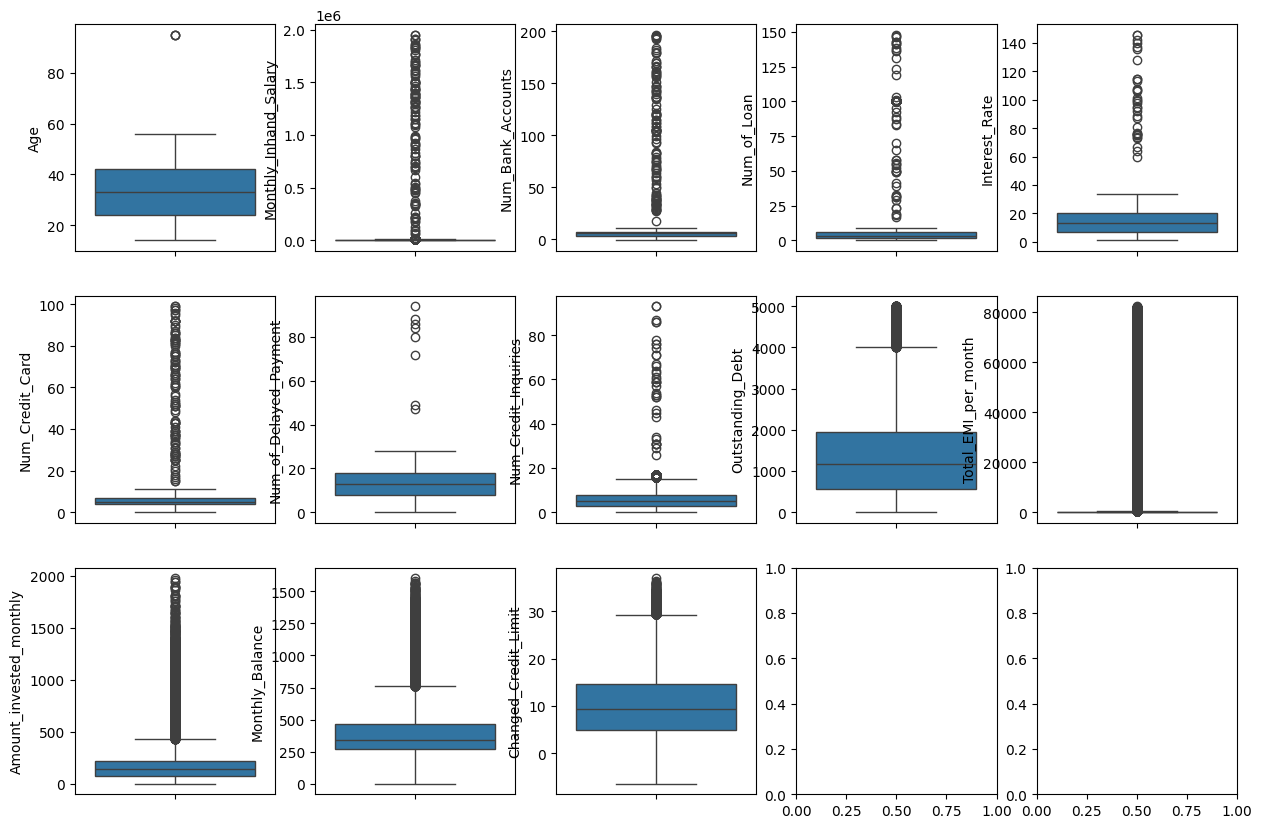

In [34]:
fig, ax = plt.subplots(3, 5, figsize=(15, 10))
sns.boxplot(y=df['Age'], ax=ax[0, 0])
sns.boxplot(y=df['Monthly_Inhand_Salary'], ax=ax[0, 1])
sns.boxplot(y=df['Num_Bank_Accounts'], ax=ax[0, 2])
sns.boxplot(y=df['Num_of_Loan'], ax=ax[0, 3])
sns.boxplot(y=df['Interest_Rate'], ax=ax[0, 4])
sns.boxplot(y=df['Num_Credit_Card'], ax=ax[1, 0])
sns.boxplot(y=df['Num_of_Delayed_Payment'], ax=ax[1, 1])
sns.boxplot(y=df['Num_Credit_Inquiries'], ax=ax[1, 2])
sns.boxplot(y=df['Outstanding_Debt'], ax=ax[1, 3])
sns.boxplot(y=df['Total_EMI_per_month'], ax=ax[1, 4])
sns.boxplot(y=df['Amount_invested_monthly'], ax=ax[2, 0])
sns.boxplot(y=df['Monthly_Balance'], ax=ax[2, 1])
sns.boxplot(y=df['Changed_Credit_Limit'], ax=ax[2, 2])

<Axes: xlabel='Credit_Score', ylabel='Changed_Credit_Limit'>

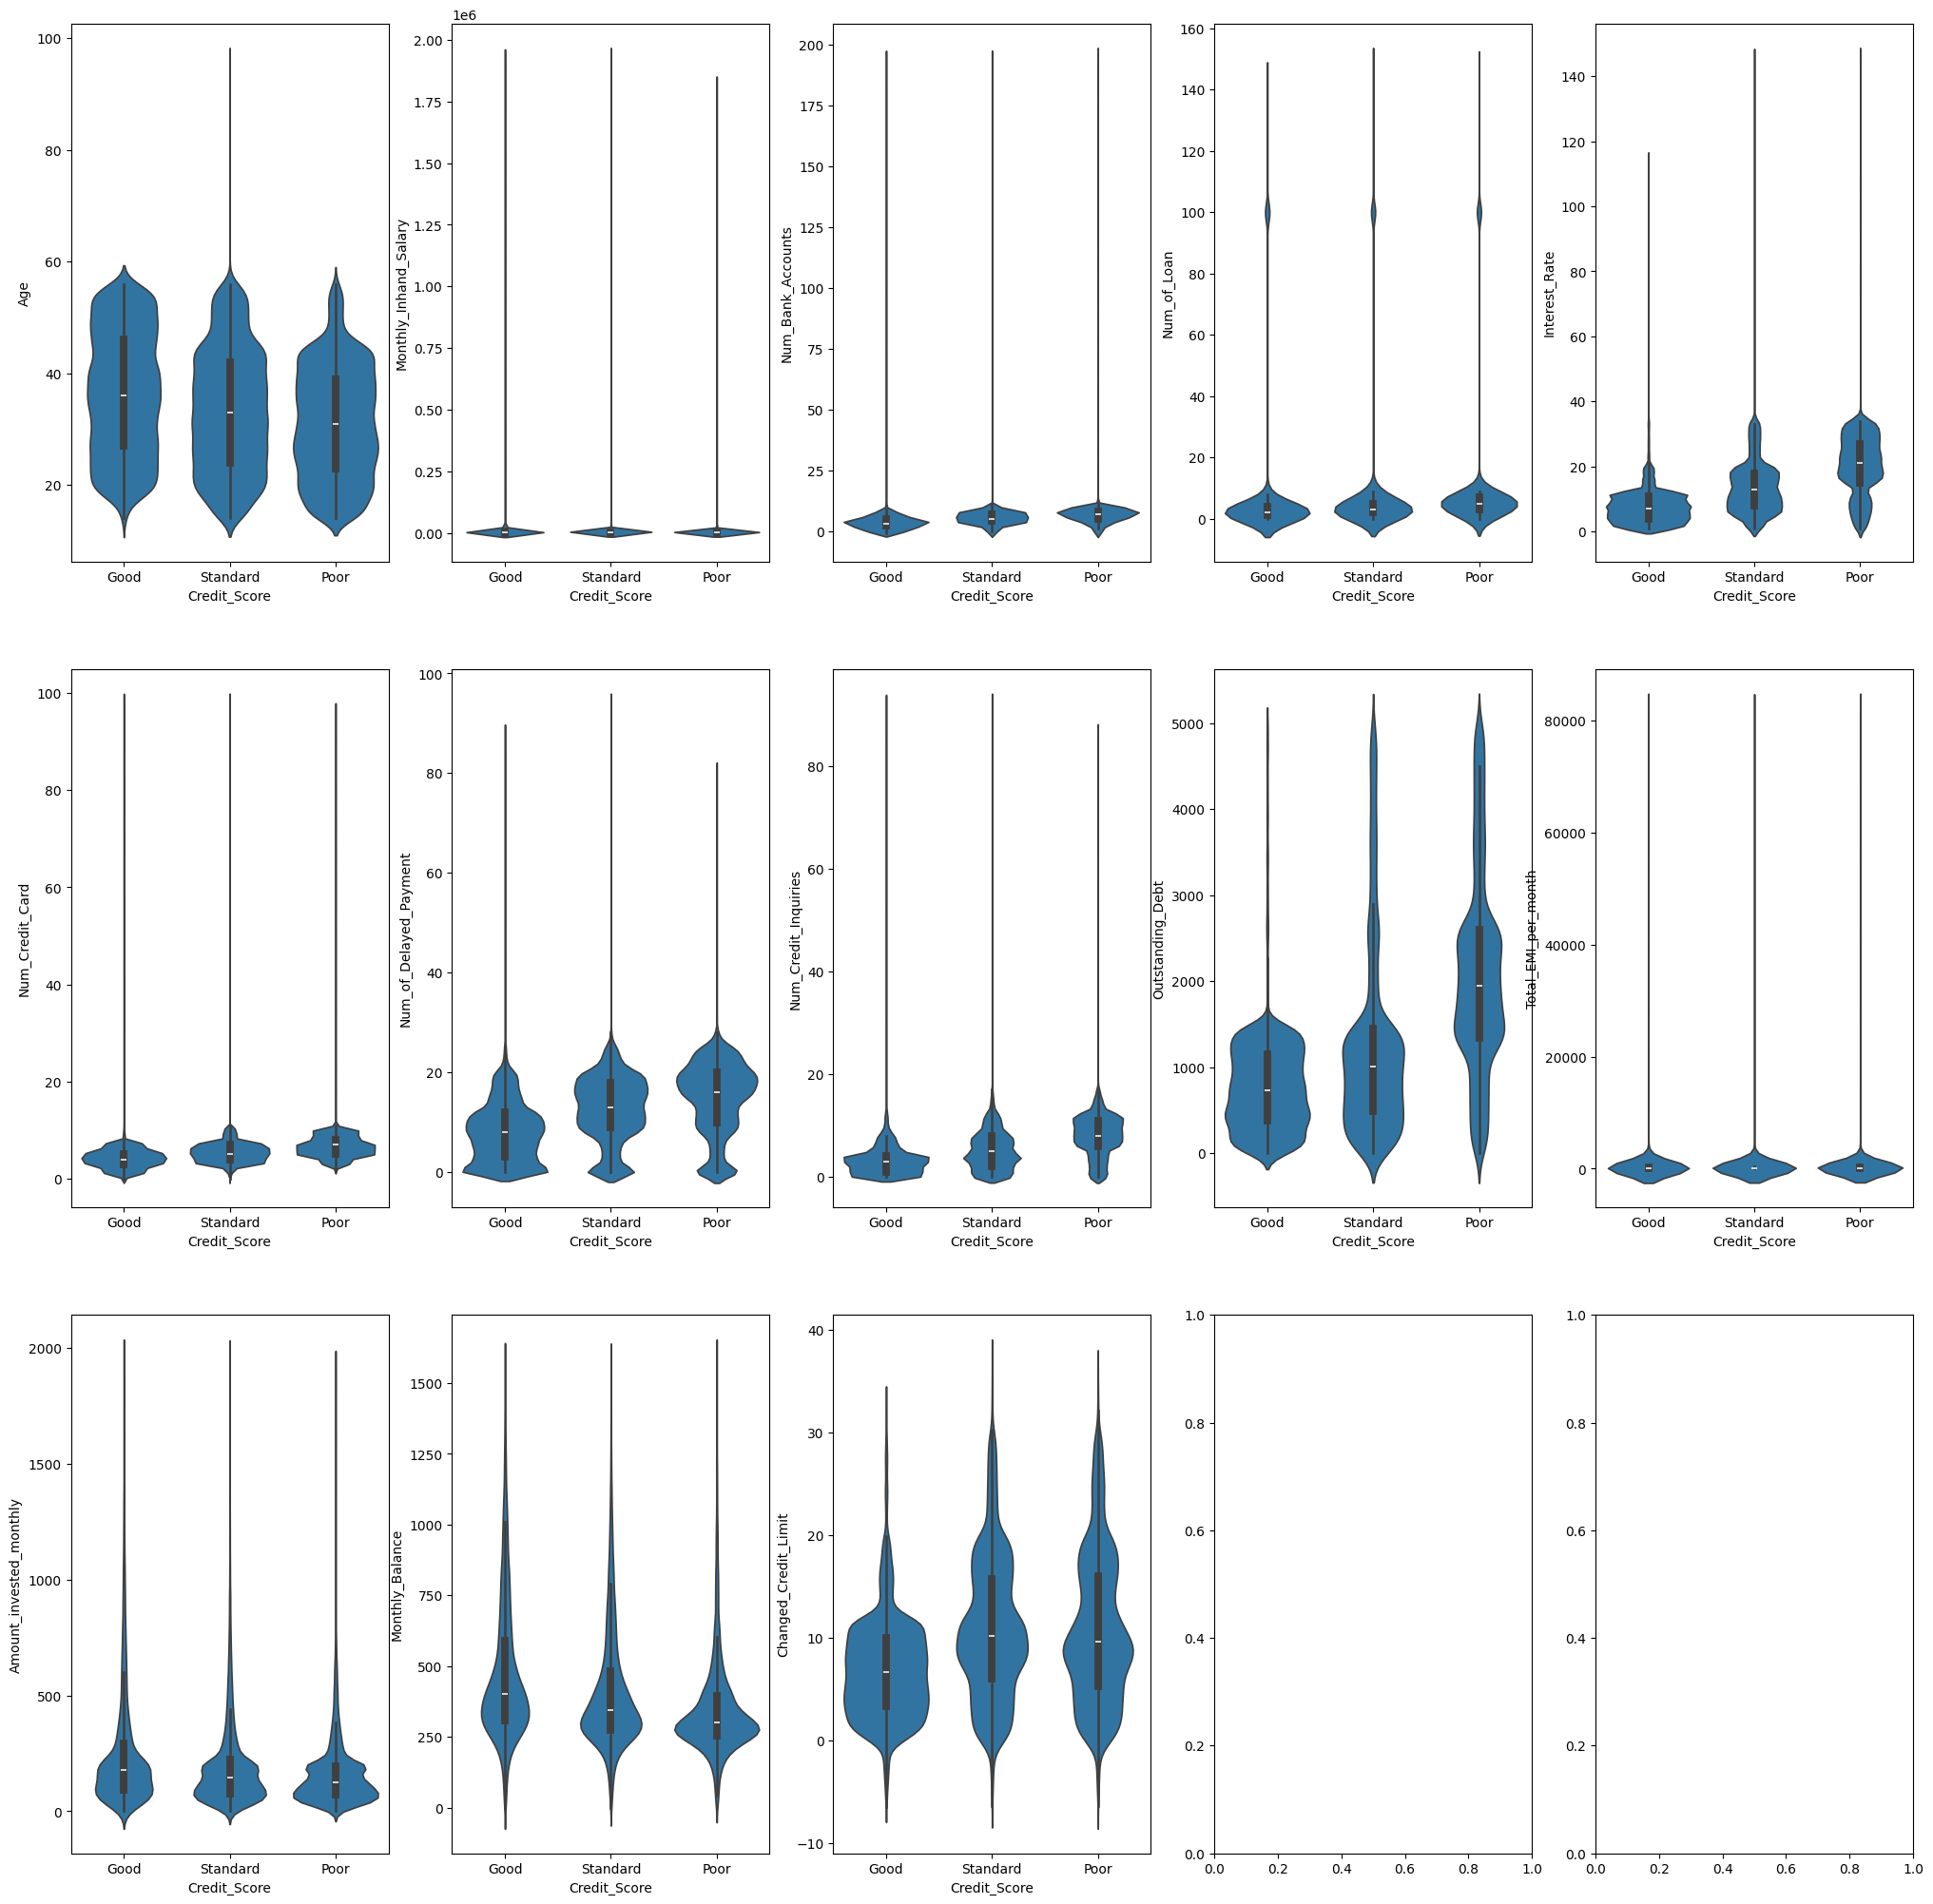

In [35]:
fig, ax = plt.subplots(3, 5, figsize=(25, 25))
sns.violinplot(data=df, x="Credit_Score", y="Age", bw=0.15, ax=ax[0, 0])
sns.violinplot(data=df, x="Credit_Score", y="Monthly_Inhand_Salary", bw=0.15, ax=ax[0, 1])
sns.violinplot(data=df, x="Credit_Score", y="Num_Bank_Accounts", bw=0.15, ax=ax[0, 2])
sns.violinplot(data=df, x="Credit_Score", y="Num_of_Loan", bw=0.15, ax=ax[0, 3])
sns.violinplot(data=df, x="Credit_Score", y="Interest_Rate", bw=0.15, ax=ax[0, 4])
sns.violinplot(data=df, x="Credit_Score", y="Num_Credit_Card", bw=0.15, ax=ax[1, 0])
sns.violinplot(data=df, x="Credit_Score", y="Num_of_Delayed_Payment", bw=0.15, ax=ax[1, 1])
sns.violinplot(data=df, x="Credit_Score", y="Num_Credit_Inquiries", bw=0.15, ax=ax[1, 2])
sns.violinplot(data=df, x="Credit_Score", y="Outstanding_Debt", bw=0.15, ax=ax[1, 3])
sns.violinplot(data=df, x="Credit_Score", y="Total_EMI_per_month", bw=0.15, ax=ax[1, 4])
sns.violinplot(data=df, x="Credit_Score", y="Amount_invested_monthly", bw=0.15, ax=ax[2, 0])
sns.violinplot(data=df, x="Credit_Score", y="Monthly_Balance", bw=0.15, ax=ax[2, 1])
sns.violinplot(data=df, x="Credit_Score", y="Changed_Credit_Limit", bw=0.15, ax=ax[2, 2])

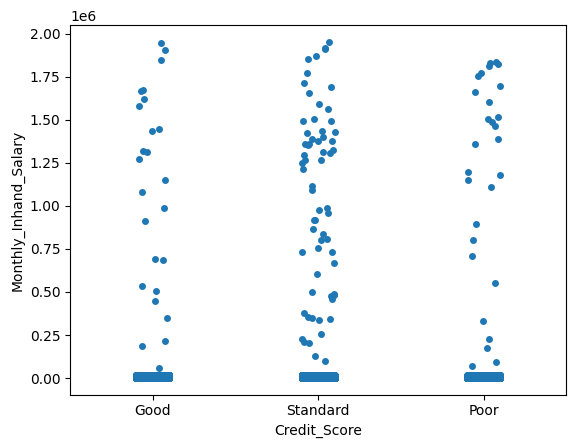

In [36]:
sns.stripplot(x='Credit_Score', y='Monthly_Inhand_Salary', data=df);

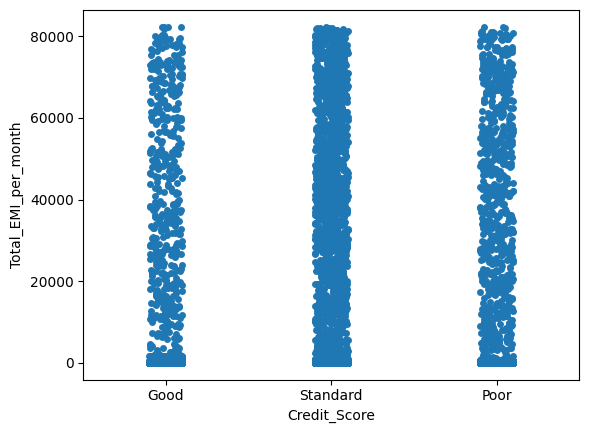

In [37]:
sns.stripplot(x='Credit_Score', y='Total_EMI_per_month', data=df);

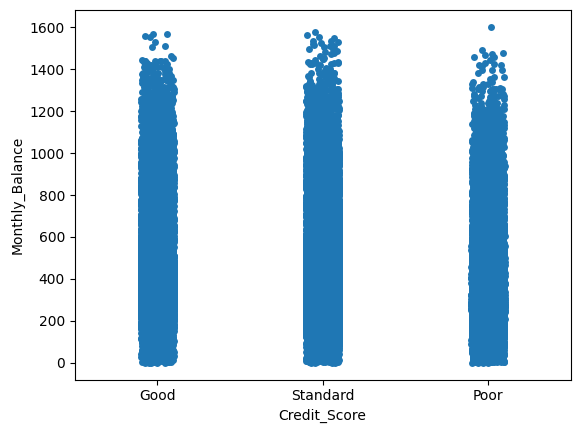

In [38]:
sns.stripplot(x='Credit_Score', y='Monthly_Balance', data=df);

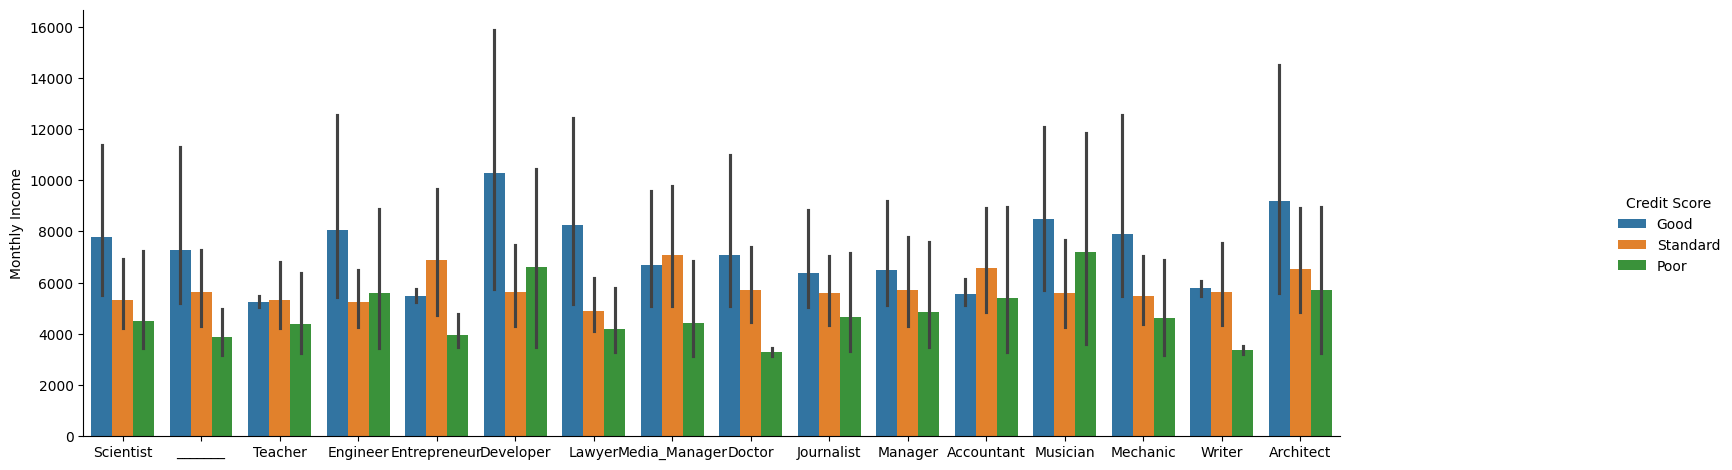

In [39]:
g = sns.catplot(
    data=df, kind="bar",
    x="Occupation", y="Monthly_Inhand_Salary", hue="Credit_Score")

g.set_axis_labels("", "Monthly Income")
g.legend.set_title("Credit Score")
plt.gcf().set_size_inches(20, 5)
plt.show()

<Axes: xlabel='Num_Credit_Card', ylabel='Num_Bank_Accounts'>

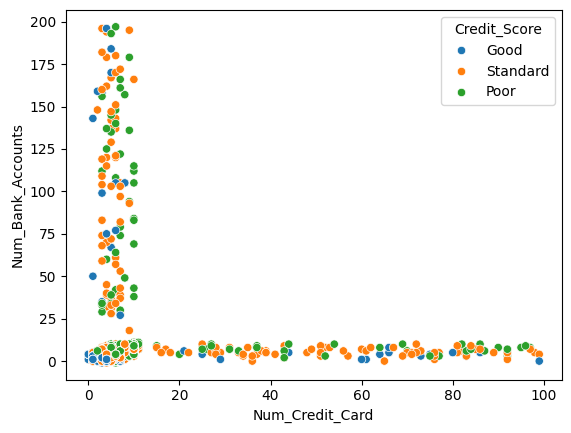

In [40]:
sns.scatterplot(x='Num_Credit_Card', y='Num_Bank_Accounts', data=df, hue='Credit_Score')

<Axes: xlabel='Interest_Rate', ylabel='Num_of_Delayed_Payment'>

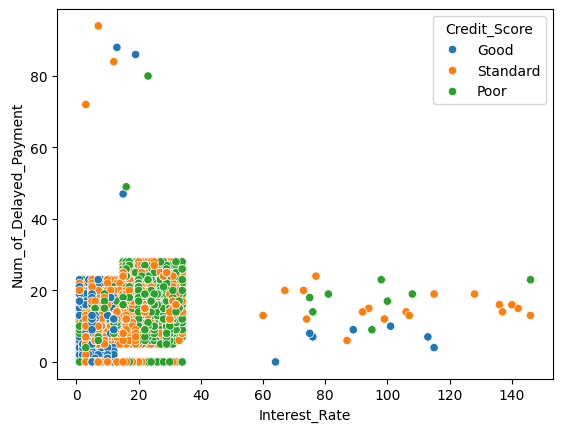

In [41]:
sns.scatterplot(x='Interest_Rate', y='Num_of_Delayed_Payment', data=df, hue='Credit_Score')

# Pre-processing

In [42]:
# Mapping month name to number [Encoding]
month_map=dict((v,k+1) for k,v in enumerate(df.Month.unique()))
df['Month'] = df['Month'].map(month_map)

In [43]:
# Credit score labeling (use dedicated encoder to avoid overwriting mappings)
from sklearn.preprocessing import LabelEncoder
le_score = LabelEncoder()
df['Credit_Score'] = le_score.fit_transform(df['Credit_Score'])

In [44]:
# Credit_Mix label (separate encoder per column - best practice)
le_credit_mix = LabelEncoder()
df['Credit_Mix_label'] = le_credit_mix.fit_transform(df['Credit_Mix'].astype(str))
df.Credit_Mix.value_counts()

,count
Credit_Mix,
Standard,37302
Good,24694
Bad,19448


In [45]:
# Payment_Behaviour label
le_payment_behaviour = LabelEncoder()
df['Payment_Behaviour_label'] = le_payment_behaviour.fit_transform(df['Payment_Behaviour'].astype(str))

In [46]:
# Payment_of_Min_Amount binary label
le_payment_min = LabelEncoder()
df['Payment_of_Min_Amount_label'] = le_payment_min.fit_transform(df['Payment_of_Min_Amount'].astype(str))

In [47]:
# encoding type of loan
le_type_loan = LabelEncoder()
df['Type_of_Loan_label'] = le_type_loan.fit_transform(df['Type_of_Loan'].astype(str))

In [48]:
le_occupation = LabelEncoder()
df['Occupation_label'] = le_occupation.fit_transform(df['Occupation'].astype(str))

In [49]:
new_df = df
df.shape

(81445, 29)

In [50]:
# Preprosseing ...!!
# Removing Outliers ..!!

df = df[(df['Age'] <= 75)] # Age outliers

df = df[(df['Interest_Rate'] <= 115)] # Interest outliers

df = df[(df['Num_of_Loan'] <= 99)] # number of loans outliers

df = df[(df['Num_of_Delayed_Payment'] <= 35)] # delayed payments outliers

df = df[(df['Num_Credit_Inquiries'] <= 80)] # Num_Credit_Inquires outliers

df = df[(df['Outstanding_Debt'] <= 4050)] # Outstanding_Debt outliers

df = df[(df['Changed_Credit_Limit'] <= 30)] # Outstanding_Debt outliers


df =  df[(df['Total_EMI_per_month'] <= 10000)] # Interest outliers


In [51]:
df=df.drop(['Occupation','Type_of_Loan','Payment_Behaviour','Credit_Mix','Payment_of_Min_Amount'],axis=1) # dropping since Encoding done...!!


# Feature selection

In [52]:
# sns.pairplot(df, hue='Credit_Score', height=2)

In [53]:
# df.corr()

In [54]:
df.Credit_Score.value_counts()

,count
Credit_Score,
2,38369
1,20199
0,13308


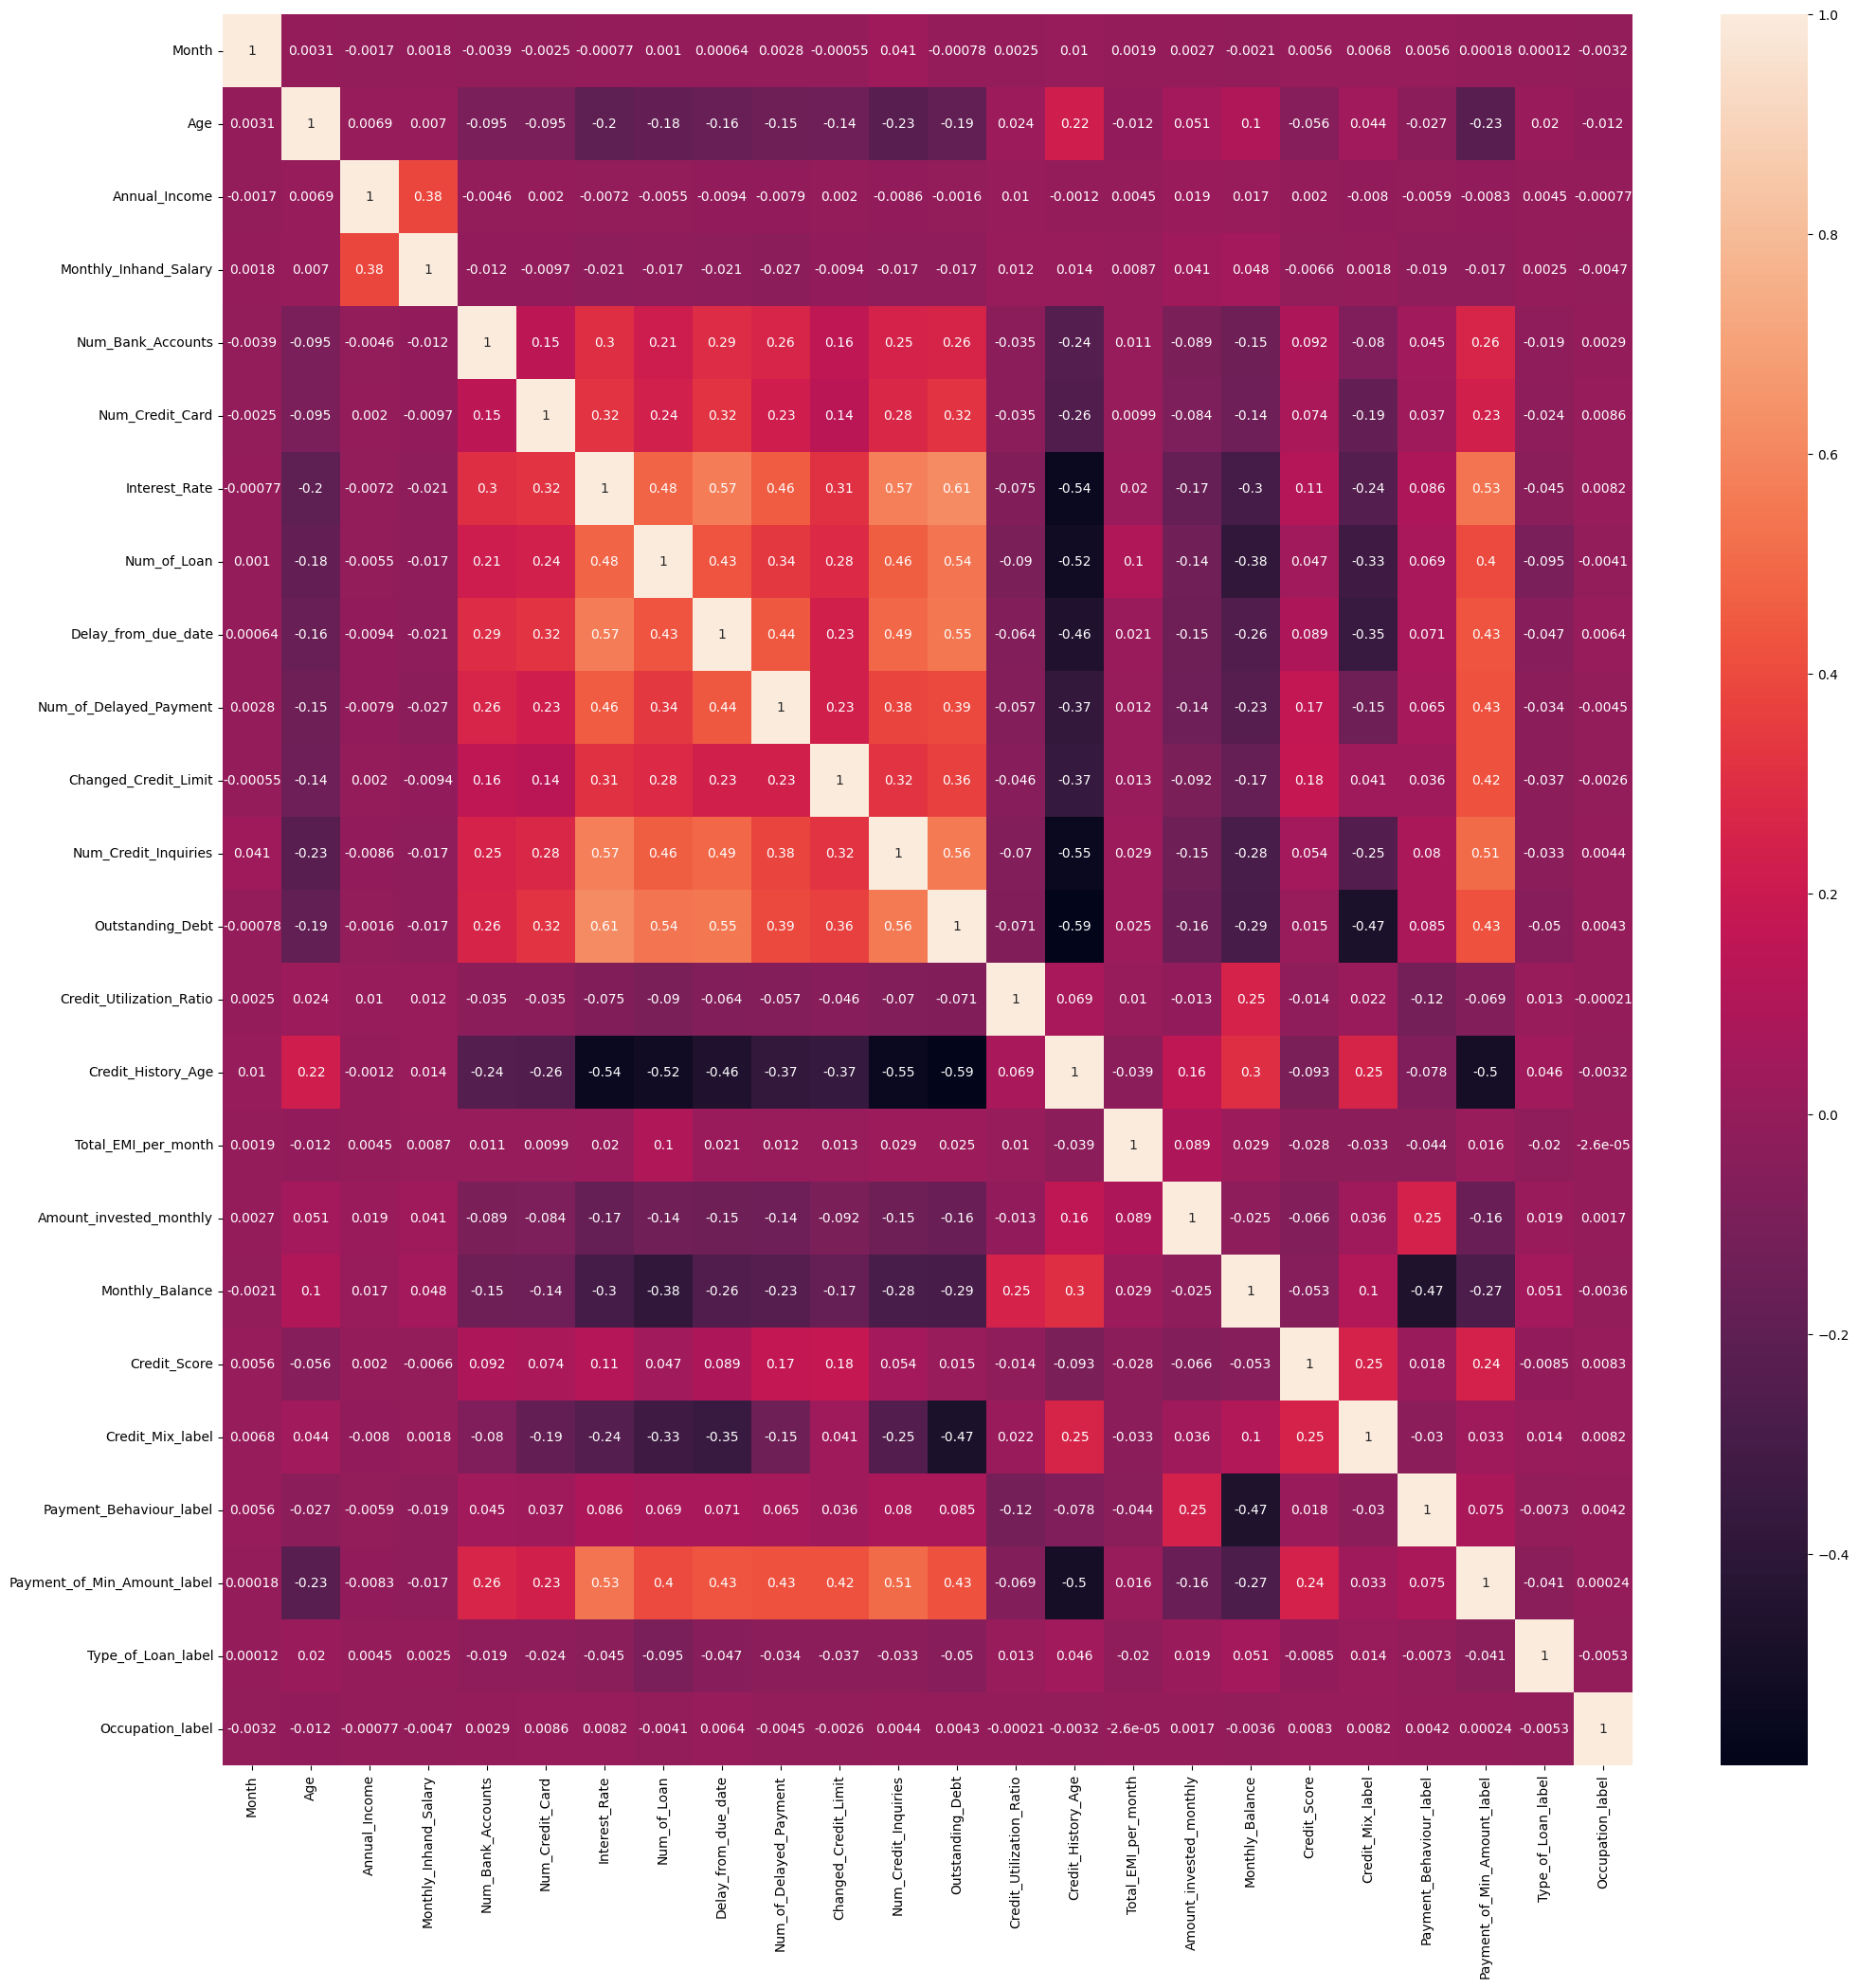

In [55]:
plt.figure(figsize = (24,24))
sns.heatmap(df.corr() , annot = True )
plt.show()

<Axes: >

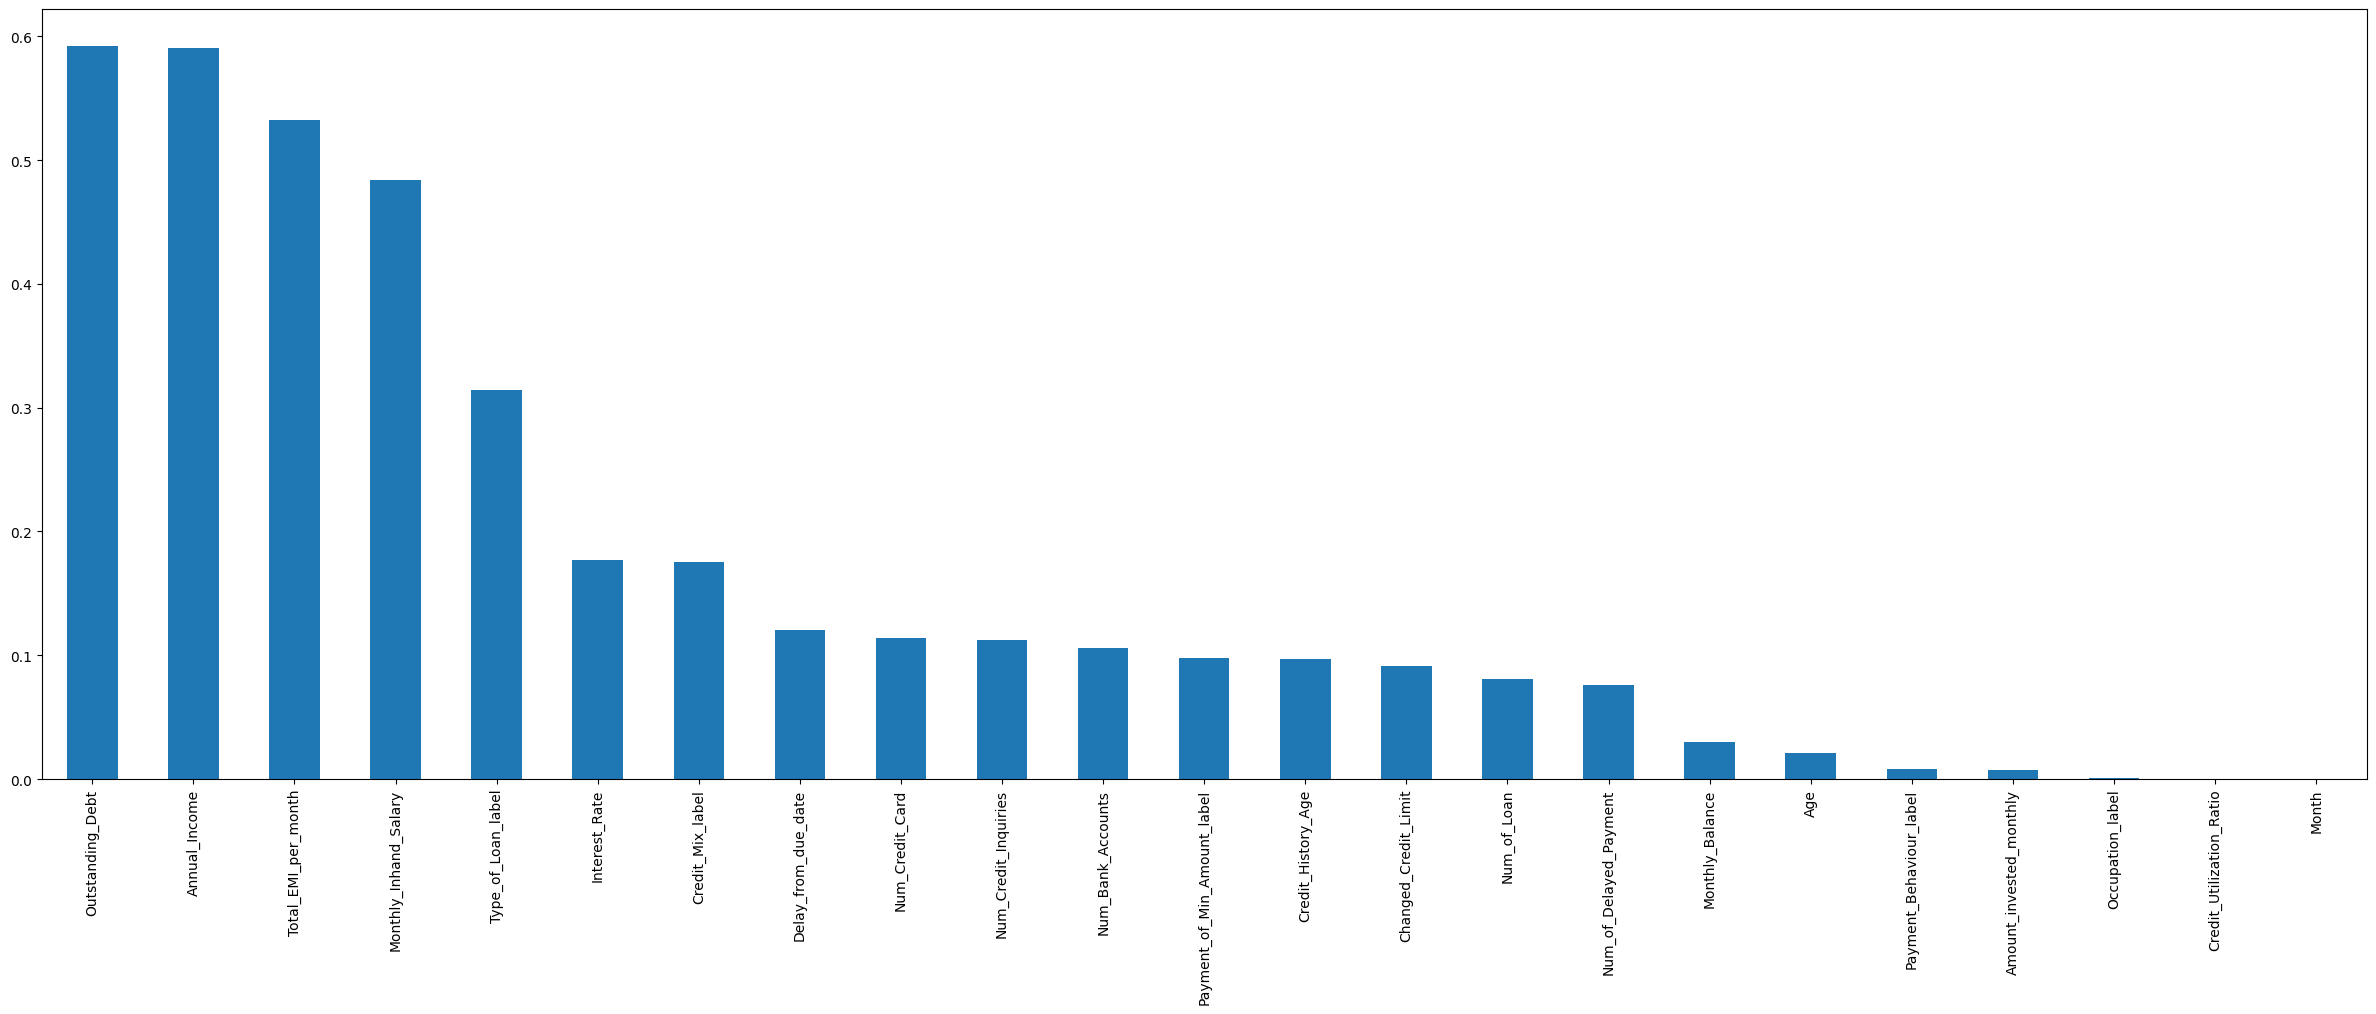

In [56]:
#finding information gain for each feature in data
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(df.drop('Credit_Score',axis=1),df['Credit_Score'])
mutual_info = pd.Series(mutual_info)
mutual_info.index = df.drop('Credit_Score',axis=1).columns
mutual_info.sort_values(ascending=False)
#plotting information gain for each feature
mutual_info.sort_values(ascending=False).plot.bar(figsize=(30, 10))

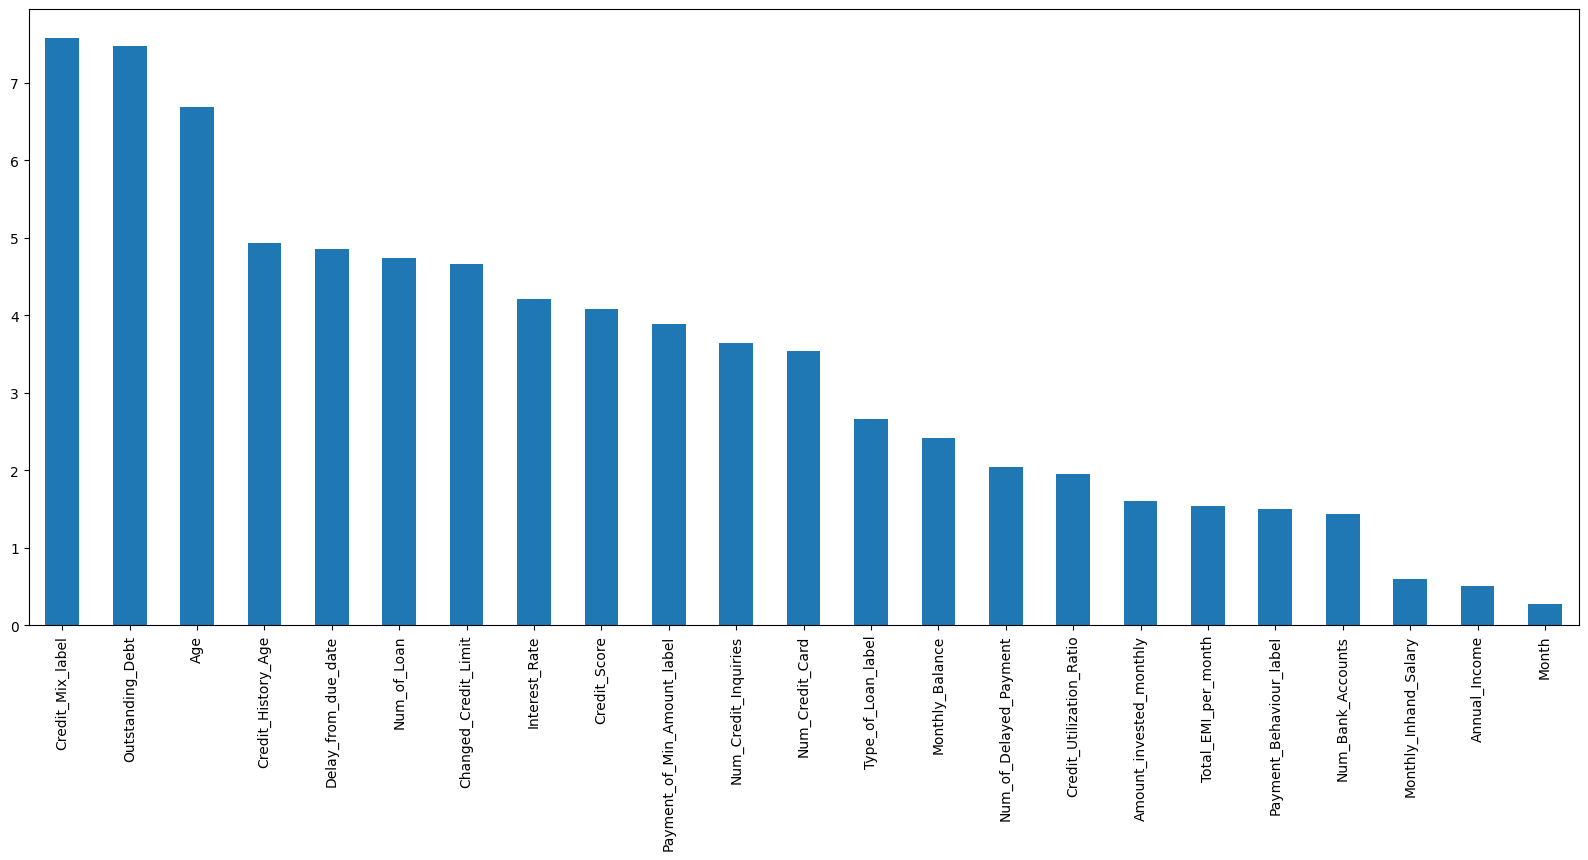

In [57]:
#calculate fisher score for feature selection
from sklearn.feature_selection import f_classif
f_score = f_classif(df.iloc[:,:-1],df.iloc[:,-1])
f_score = pd.Series(f_score[0])
f_score.index = df.iloc[:,:-1].columns
f_score.sort_values(ascending=False)
#plot fisher score
f_score.sort_values(ascending=False).plot.bar(figsize=(20,8))
plt.show()

In [58]:
df = df.drop(['Credit_Utilization_Ratio','Occupation_label','Month','Payment_Behaviour_label','Age'],axis=1)

In [59]:
df.to_csv('train_cleaned.csv',index=False)


# Applying Models

In [60]:
df = pd.read_csv("train_cleaned.csv")

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler
X = df.drop('Credit_Score',axis=1)
y = df['Credit_Score']
# Stratified split keeps class balance in train/test (best practice for classification)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
# Scale features (fit on train only to avoid leakage); helps LR, KNN, SVM; tree models are scale-invariant
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Quick check: cross-validation score vs single split (helps spot overfitting)
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
rf_check = RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf_check, X_train, y_train, cv=3, scoring='accuracy')
print(f'CV accuracy (3-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')
print('If test accuracy is much higher than CV, the model may be overfitting.')

In [62]:
from sklearn.preprocessing import PowerTransformer
scalar = PowerTransformer(method='yeo-johnson', standardize=True).fit(X_train)
X_train = scalar.transform(X_train)
X_test = scalar.transform(X_test)

In [63]:
# logistic regression
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train,y_train)
y_pred = log_reg.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.6530328324986088
              precision    recall  f1-score   support

           0       0.58      0.49      0.53      2651
           1       0.66      0.55      0.60      3968
           2       0.67      0.76      0.71      7757

    accuracy                           0.65     14376
   macro avg       0.64      0.60      0.61     14376
weighted avg       0.65      0.65      0.65     14376



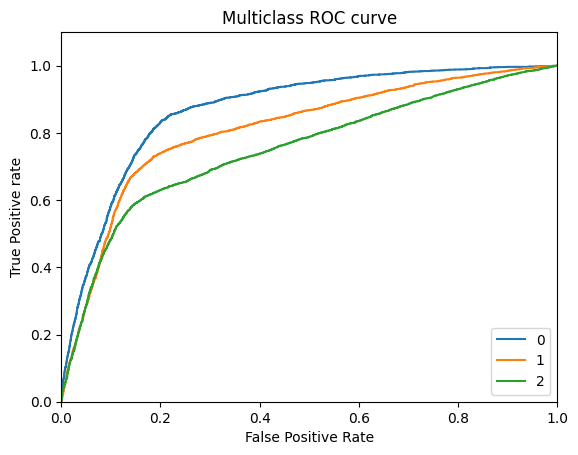

In [64]:
## Reference -> GFG
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,auc
from sklearn.preprocessing import label_binarize

fpr = {}

roc_cu  = LogisticRegression(max_iter=5000)

uniqueee =  np.unique(y_test)

roc_cu.fit(X_train,y_train)

binaryii=label_binarize(y_test,classes=uniqueee)

pred_prob =roc_cu.predict_proba(X_test)

y_pred =roc_cu.predict(X_test)
roc_auc = dict()


tpr = {}


for i in range(0,3):
    fpr[i], tpr[i], thresh = roc_curve(binaryii[:,i], pred_prob[:,i])
    ap = 1
    roc_auc[i] = auc(fpr[i], tpr[i])

    d=1

    plt.plot(fpr[i], tpr[i],label='%s'%(i))

plt.xlabel('False Positive Rate')
plt.xlim([0,1])
plt.title('Multiclass ROC curve')
plt.legend(loc='lower right')
plt.ylabel('True Positive rate')
plt.ylim([0,1.1])

plt.show()

# 0 - good
# 1 - poor
# 2 - standard


In [65]:
# Applying Naive Bayes (using stratified, scaled train/test from cell above)
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

model = GaussianNB()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.5928631051752922
              precision    recall  f1-score   support

           0       0.37      0.23      0.28      2651
           1       0.63      0.59      0.61      3968
           2       0.62      0.72      0.67      7757

    accuracy                           0.59     14376
   macro avg       0.54      0.51      0.52     14376
weighted avg       0.58      0.59      0.58     14376



In [66]:
# Applying decision tree with information gain (using train/test from above)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
dt = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7186978297161937
              precision    recall  f1-score   support

           0       0.59      0.65      0.62      2651
           1       0.73      0.69      0.71      3968
           2       0.76      0.76      0.76      7757

    accuracy                           0.72     14376
   macro avg       0.69      0.70      0.70     14376
weighted avg       0.72      0.72      0.72     14376



In [67]:
# Applying decision tree with Gini index (using train/test from above)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
dt = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
print(accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

0.7269059543683918
              precision    recall  f1-score   support

           0       0.58      0.71      0.64      2651
           1       0.74      0.70      0.72      3968
           2       0.78      0.75      0.76      7757

    accuracy                           0.73     14376
   macro avg       0.70      0.72      0.71     14376
weighted avg       0.73      0.73      0.73     14376



In [68]:
# Applying random forest (using train/test from above; constrained to reduce overfitting)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=100, random_state=42)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
#accuracy score
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8087785197551475
              precision    recall  f1-score   support

           0       0.78      0.76      0.77      2651
           1       0.79      0.83      0.81      3968
           2       0.83      0.82      0.82      7757

    accuracy                           0.81     14376
   macro avg       0.80      0.80      0.80     14376
weighted avg       0.81      0.81      0.81     14376



In [69]:
import gc
gc.collect()

52980

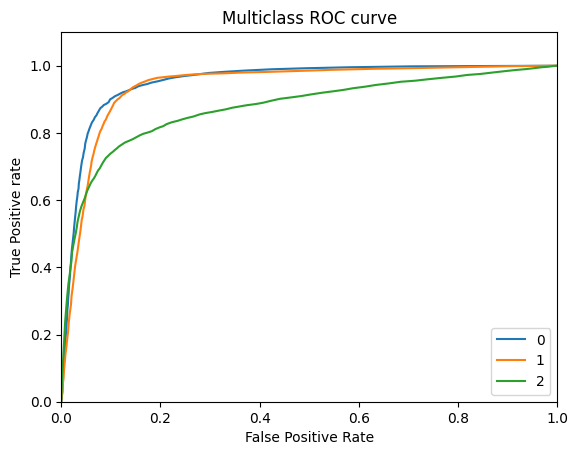

In [70]:
## Reference -> GFG
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,auc
from sklearn.preprocessing import label_binarize

fpr = {}


uniqueee =  np.unique(y_test)

binaryii=label_binarize(y_test,classes=uniqueee)

pred_prob =rf.predict_proba(X_test)

y_pred =rf.predict(X_test)
roc_auc = dict()


tpr = {}


for i in range(0,3):
    fpr[i], tpr[i], thresh = roc_curve(binaryii[:,i], pred_prob[:,i])
    ap = 1
    roc_auc[i] = auc(fpr[i], tpr[i])

    d=1

    plt.plot(fpr[i], tpr[i],label='%s'%(i))

plt.xlabel('False Positive Rate')
plt.xlim([0,1])
plt.title('Multiclass ROC curve')
plt.legend(loc='lower right')
plt.ylabel('True Positive rate')
plt.ylim([0,1.1])

plt.show()

# 0 - good
# 1 - poor
# 2 - standard


Text(0.5, 1.0, 'Visualising Important Features')

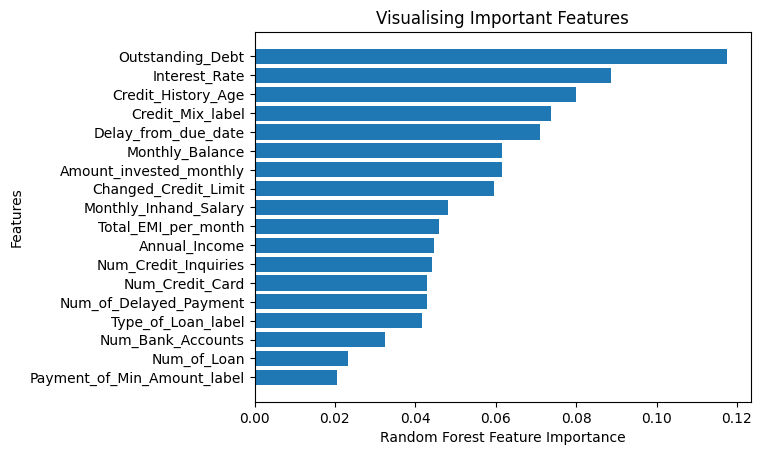

In [71]:
sorted_idx = rf.feature_importances_.argsort()
plt.barh(rf.feature_names_in_[sorted_idx], rf.feature_importances_[sorted_idx])
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Features")
plt.title("Visualising Important Features")

In [72]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [73]:
# Free up memory before running GridSearch
import gc
gc.collect()

36

In [74]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [80, 100, 130, 160],
    'max_depth': [10, 15, 20, 25],
    'min_samples_leaf': [3, 5, 7],
    'criterion': ['gini', 'entropy']
}

random_search_rf = RandomizedSearchCV(estimator=rf, param_distributions=param_grid,
                                      n_iter=8, cv=3, n_jobs=1, verbose=2, random_state=42)
random_search_rf.fit(X_train, y_train)
random_search_rf.best_params_

Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END criterion=entropy, max_depth=None, n_estimators=100; total time=  13.5s
[CV] END criterion=entropy, max_depth=None, n_estimators=100; total time=  14.7s
[CV] END ...criterion=gini, max_depth=None, n_estimators=130; total time=  15.4s
[CV] END ...criterion=gini, max_depth=None, n_estimators=130; total time=  15.8s
[CV] END ...criterion=entropy, max_depth=20, n_estimators=80; total time=  10.3s
[CV] END ...criterion=entropy, max_depth=20, n_estimators=80; total time=   9.8s
[CV] END ..criterion=entropy, max_depth=10, n_estimators=100; total time=   7.9s
[CV] END ..criterion=entropy, max_depth=10, n_estimators=100; total time=   8.5s
[CV] END ......criterion=gini, max_depth=20, n_estimators=80; total time=  12.6s
[CV] END ......criterion=gini, max_depth=20, n_estimators=80; total time=   8.7s


{'n_estimators': 130, 'max_depth': None, 'criterion': 'gini'}

In [75]:
import gc
gc.collect()

184

In [76]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [130, 160, 200],
    'max_depth': [15, 20, 25],
    'criterion': ['gini', 'entropy']
}

grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid,
                              cv=3, n_jobs=1, verbose=2)
grid_search_rf.fit(X_train, y_train)
grid_search_rf.best_params_

Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV] END ...criterion=gini, max_depth=None, n_estimators=130; total time=  15.8s
[CV] END ...criterion=gini, max_depth=None, n_estimators=130; total time=  15.5s
[CV] END ...criterion=gini, max_depth=None, n_estimators=160; total time=  20.0s
[CV] END ...criterion=gini, max_depth=None, n_estimators=160; total time=  19.2s
[CV] END ...criterion=gini, max_depth=None, n_estimators=200; total time=  23.8s
[CV] END ...criterion=gini, max_depth=None, n_estimators=200; total time=  23.6s
[CV] END ...criterion=gini, max_depth=None, n_estimators=230; total time=  27.4s
[CV] END ...criterion=gini, max_depth=None, n_estimators=230; total time=  36.6s
[CV] END criterion=entropy, max_depth=None, n_estimators=130; total time=  17.8s
[CV] END criterion=entropy, max_depth=None, n_estimators=130; total time=  16.9s
[CV] END criterion=entropy, max_depth=None, n_estimators=160; total time=  21.4s
[CV] END criterion=entropy, max_depth=None, n_est

{'criterion': 'gini', 'max_depth': None, 'n_estimators': 230}

In [77]:
import gc
gc.collect()

299

In [78]:
from sklearn.ensemble import RandomForestClassifier
# Constrain max_depth and min_samples_leaf to reduce overfitting (was max_depth=None)
rf_cv = RandomForestClassifier(criterion='gini', max_depth=20, n_estimators=200, min_samples_leaf=5, random_state=42)
rf_cv.fit(X_train,y_train)
y_pred = rf_cv.predict(X_test)
print('Test accuracy:', accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8101001669449082
              precision    recall  f1-score   support

           0       0.78      0.76      0.77      2651
           1       0.79      0.83      0.81      3968
           2       0.84      0.81      0.82      7757

    accuracy                           0.81     14376
   macro avg       0.80      0.80      0.80     14376
weighted avg       0.81      0.81      0.81     14376



0.6931691708402894


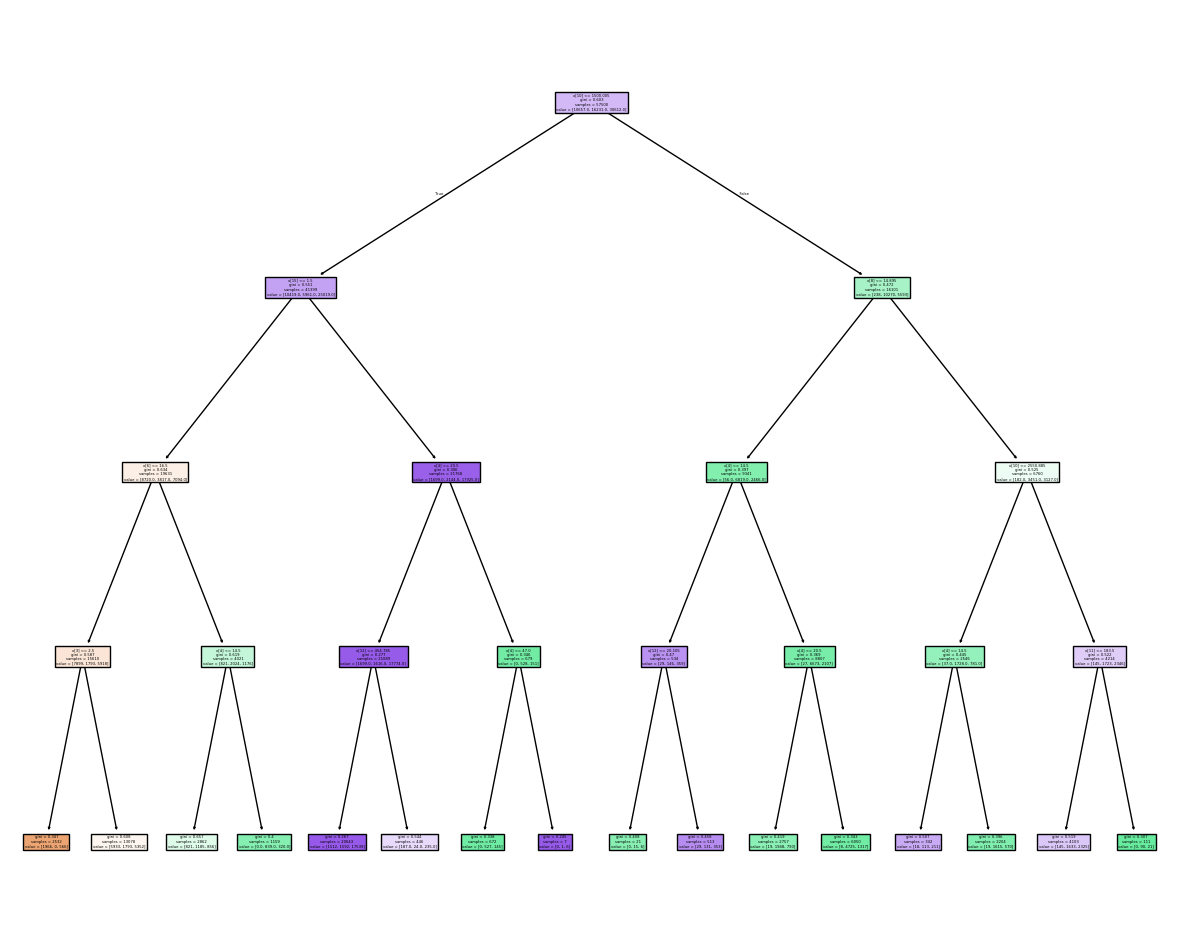

In [79]:
from sklearn import tree

#to a simple plot,We used max depth of 4
dtt = DecisionTreeClassifier(max_depth=4, random_state=42)

dtt.fit(X_train, y_train)
y_pred = dtt.predict(X_test)
print(accuracy_score(y_test,y_pred))
fig = plt.figure(figsize=(15,12))
tree.plot_tree(dtt , filled=True)
plt.show()

### KNN

In [80]:
from sklearn.neighbors import KNeighborsClassifier
knc = KNeighborsClassifier()
knc.fit(X_train,y_train)
y_pred = knc.predict(X_test)
#accuracy score
acc_score = accuracy_score(y_test, y_pred)  # evaluating accuracy
print('accuracy score of KNN model:', acc_score * 100)
print(classification_report(y_test,y_pred))

accuracy score of KNN model: 74.909571508069
              precision    recall  f1-score   support

           0       0.65      0.64      0.65      2651
           1       0.74      0.78      0.76      3968
           2       0.79      0.77      0.78      7757

    accuracy                           0.75     14376
   macro avg       0.73      0.73      0.73     14376
weighted avg       0.75      0.75      0.75     14376



In [81]:
# Avoid n_neighbors=1 (severe overfitting); search 5–30
k_range = list(range(5, 31))
param_grid = dict(n_neighbors=k_range)
grid_knn = GridSearchCV(knc, param_grid, cv=5, scoring='accuracy', return_train_score=False, verbose=1)

# fitting the model for grid search
grid_search_knn=grid_knn.fit(X_train, y_train)
print(grid_search_knn.best_params_)
accuracy = grid_search_knn.best_score_ *100
print("Accuracy for our training dataset with tuning is : "+str(accuracy)+"%")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'n_neighbors': 1}
Accuracy for our training dataset with tuning is : 74.1391304347826%


In [82]:
# KNN: n_neighbors=1 causes severe overfitting; use 15–25 for better generalization (features are already scaled above)
knc_cv = KNeighborsClassifier(n_neighbors=15, weights='distance', metric='minkowski', p=2)
knc_cv.fit(X_train,y_train)
y_pred = knc_cv.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)
print('Accuracy for our testing dataset with tuning is:', acc_score * 100)
print(classification_report(y_test,y_pred))

Accuracy for our testing dataset with tuning is: 76.17557039510295
              precision    recall  f1-score   support

           0       0.71      0.71      0.71      2651
           1       0.75      0.76      0.76      3968
           2       0.78      0.78      0.78      7757

    accuracy                           0.76     14376
   macro avg       0.75      0.75      0.75     14376
weighted avg       0.76      0.76      0.76     14376



In [83]:
from sklearn.ensemble import  StackingClassifier

In [84]:
clf_stack = StackingClassifier([('knn_1nn',knc_cv),('rf',rf_cv)])

model_stack = clf_stack.fit(X_train, y_train)   # training of stacked model
pred_stack = model_stack.predict(X_test)


acc_stack = accuracy_score(y_test, pred_stack)  # evaluating accuracy
print('accuracy score of Stacked model:', acc_stack * 100)
print(classification_report(y_test,pred_stack))

accuracy score of Stacked model: 80.87089593767391
              precision    recall  f1-score   support

           0       0.79      0.75      0.77      2651
           1       0.80      0.81      0.80      3968
           2       0.82      0.83      0.82      7757

    accuracy                           0.81     14376
   macro avg       0.80      0.80      0.80     14376
weighted avg       0.81      0.81      0.81     14376



In [85]:
import gc
gc.collect()

234

### XGB

In [86]:
from xgboost import XGBClassifier
# Constrain depth and use early stopping to reduce overfitting
XGB = XGBClassifier(n_jobs=-1, max_depth=8, n_estimators=200, random_state=42)
XGB.fit(X_train, y_train)
y_pred = XGB.predict(X_test)
#accuracy score
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7661380077907624
              precision    recall  f1-score   support

           0       0.68      0.72      0.70      2651
           1       0.76      0.76      0.76      3968
           2       0.80      0.79      0.79      7757

    accuracy                           0.77     14376
   macro avg       0.75      0.75      0.75     14376
weighted avg       0.77      0.77      0.77     14376



In [87]:
grid_search_xgb = GridSearchCV(estimator = XGB, param_grid = {'n_estimators':(40, 50, 80,100,125,150,200,250,300,400,500)}, n_jobs = -1).fit(X_train,y_train)
print(grid_search_xgb.best_params_)
accuracy = grid_search_xgb.best_score_ *100
print("Accuracy for our training dataset with tuning is : "+str(accuracy)+"%")

{'n_estimators': 500}
Accuracy for our training dataset with tuning is : 77.42956521739131%


In [88]:
from xgboost import XGBClassifier
# Constrain max_depth and n_estimators to reduce overfitting
XGB_cv = XGBClassifier(n_estimators=200, max_depth=8, n_jobs=-1, random_state=42)
XGB_cv.fit(X_train, y_train)
y_pred = XGB_cv.predict(X_test)
#accuracy score
from sklearn.metrics import accuracy_score
acc_score = accuracy_score(y_test,y_pred)
print('Accuracy for our testing dataset with tuning is:', acc_score * 100)
print(classification_report(y_test,y_pred))

Accuracy for our testing dataset with tuning is: 79.78575403450195
              precision    recall  f1-score   support

           0       0.77      0.74      0.75      2651
           1       0.78      0.80      0.79      3968
           2       0.82      0.82      0.82      7757

    accuracy                           0.80     14376
   macro avg       0.79      0.79      0.79     14376
weighted avg       0.80      0.80      0.80     14376



In [89]:
clf_stack = StackingClassifier([('knn_1nn',knc_cv),('xgb',XGB_cv),('rf',rf_cv)])

model_stack = clf_stack.fit(X_train, y_train)   # training of stacked model
pred_stack = model_stack.predict(X_test)


acc_stack = accuracy_score(y_test, pred_stack)  # evaluating accuracy
print('accuracy score of Stacked model:', acc_stack * 100)
print(classification_report(y_test,pred_stack))

accuracy score of Stacked model: 80.5370061213133
              precision    recall  f1-score   support

           0       0.79      0.75      0.77      2651
           1       0.79      0.80      0.80      3968
           2       0.82      0.83      0.82      7757

    accuracy                           0.81     14376
   macro avg       0.80      0.79      0.80     14376
weighted avg       0.81      0.81      0.81     14376



In [90]:
import gc
gc.collect()

259

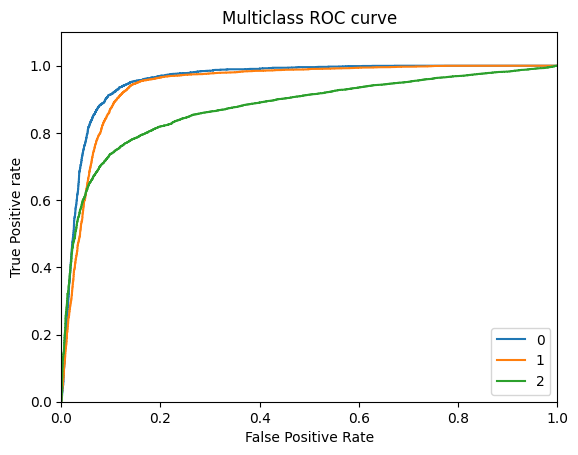

In [91]:
## Reference -> GFG
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,auc
from sklearn.preprocessing import label_binarize

fpr = {}


uniqueee =  np.unique(y_test)


binaryii=label_binarize(y_test,classes=uniqueee)

pred_prob =clf_stack.predict_proba(X_test)

y_pred =clf_stack.predict(X_test)
roc_auc = dict()


tpr = {}


for i in range(0,3):
    fpr[i], tpr[i], thresh = roc_curve(binaryii[:,i], pred_prob[:,i])
    ap = 1
    roc_auc[i] = auc(fpr[i], tpr[i])

    d=1

    plt.plot(fpr[i], tpr[i],label='%s'%(i))

plt.xlabel('False Positive Rate')
plt.xlim([0,1])
plt.title('Multiclass ROC curve')
plt.legend(loc='lower right')
plt.ylabel('True Positive rate')
plt.ylim([0,1.1])

plt.show()

# 0 - good
# 1 - poor
# 2 - standard


# MLP bagging

In [92]:
from sklearn.neural_network import MLPClassifier
from sklearn.utils import shuffle

In [93]:
clf = MLPClassifier(random_state=1, max_iter=300).fit(X_train, y_train)

In [94]:
y_pred = clf.predict(X_test)
#accuracy score
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.5900806900389538
              precision    recall  f1-score   support

           0       0.48      0.01      0.03      2651
           1       0.64      0.39      0.48      3968
           2       0.58      0.89      0.70      7757

    accuracy                           0.59     14376
   macro avg       0.57      0.43      0.40     14376
weighted avg       0.58      0.59      0.52     14376



In [95]:
# Use existing stratified, scaled X_train, X_test, y_train, y_test from above
li_clf = []

for i in range(0, 100):
    p_train, t_train = shuffle(X_train, y_train, random_state=i)
    p_train_new, dump, t_train_new, dump2 = train_test_split(p_train, t_train, test_size=0.5, random_state=42)
    clf = MLPClassifier(random_state=i, max_iter=300, early_stopping=True, validation_fraction=0.1).fit(p_train_new, t_train_new)
    li_clf.append(clf)

In [97]:
li_out = []
y_pred = []

for i in range(0,len(X_test)):
        li_out.append([])
for model in li_clf:
    pred = model.predict(X_test)
    for i in range(0,len(pred)):
        li_out[i].append(pred[i])

for i in li_out:
    y_pred.append(max(set(i), key=i.count))

#check accuracy
print("Accuracy of neural network classifier: ", accuracy_score(y_test, y_pred))
#check f1 score
print("F1 score of neural network classifier: ", f1_score(y_test, y_pred, average='weighted'))
#check precision score
print("Precision score of neural network classifier: ", precision_score(y_test, y_pred, average='weighted'))
#check recall score
print("Recall score of neural network classifier: ", recall_score(y_test, y_pred, average='weighted'))

Accuracy of neural network classifier:  0.6271563717306622
F1 score of neural network classifier:  0.603101549166556
Precision score of neural network classifier:  0.6168018045373379
Recall score of neural network classifier:  0.6271563717306622


## Extra Tree Classifier

In [98]:
from sklearn.ensemble import ExtraTreesClassifier
ETC= ExtraTreesClassifier(n_estimators = 100,bootstrap = True)
ETC.fit(X_train, y_train)
y_pred = ETC.predict(X_test)
#accuracy score
acc_score = accuracy_score(y_test, y_pred)  # evaluating accuracy
print('accuracy score of ExtraTreesClassifier model:', acc_score * 100)
print(classification_report(y_test,y_pred))

accuracy score of ExtraTreesClassifier model: 79.84140233722871
              precision    recall  f1-score   support

           0       0.76      0.75      0.75      2651
           1       0.78      0.81      0.79      3968
           2       0.82      0.81      0.82      7757

    accuracy                           0.80     14376
   macro avg       0.79      0.79      0.79     14376
weighted avg       0.80      0.80      0.80     14376



In [99]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
clf_stack = StackingClassifier([('etc', ExtraTreesClassifier(n_estimators=100, bootstrap=True, max_depth=20)), ('rf', RandomForestClassifier(criterion='gini', max_depth=20, n_estimators=200, random_state=42))])

model_stack = clf_stack.fit(X_train, y_train)   # training of stacked model
pred_stack = model_stack.predict(X_test)


acc_stack = accuracy_score(y_test, pred_stack)  # evaluating accuracy
print('accuracy score of Stacked model:', acc_stack * 100)

accuracy score of Stacked model: 80.66221480244853


In [103]:
# SVM - Fast version for large data
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svc = LinearSVC(max_iter=2000)  # LinearSVC is much faster than SVC
svc.fit(X_train, y_train)
print(classification_report(y_train, svc.predict(X_train)))
print('Model accuracy score with default hyperparameters: {0:0.4f}'.format(
    accuracy_score(y_test, svc.predict(X_test))))

              precision    recall  f1-score   support

           0       0.51      0.11      0.18     10657
           1       0.66      0.53      0.59     16231
           2       0.60      0.83      0.70     30612

    accuracy                           0.61     57500
   macro avg       0.59      0.49      0.49     57500
weighted avg       0.60      0.61      0.57     57500

Model accuracy score with default hyperparameters: 0.6199


In [104]:
results = {
    'Logistic Regression': accuracy_score(y_test, log_reg.predict(X_test)),
    'Naive Bayes': accuracy_score(y_test, model.predict(X_test)),
    'Decision Tree': accuracy_score(y_test, dt.predict(X_test)),
    'Random Forest (tuned)': accuracy_score(y_test, rf_cv.predict(X_test)),
    'KNN (tuned)': accuracy_score(y_test, knc_cv.predict(X_test)),
    'XGBoost (tuned)': accuracy_score(y_test, XGB_cv.predict(X_test)),
    'Stacking (KNN+XGB+RF)': accuracy_score(y_test, clf_stack.predict(X_test)),
    'SVM (LinearSVC)': 0.6199
}

for model_name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:30s}: {acc*100:.2f}%")

Random Forest (tuned)         : 81.01%
Stacking (KNN+XGB+RF)         : 80.66%
XGBoost (tuned)               : 79.79%
KNN (tuned)                   : 76.18%
Decision Tree                 : 72.69%
SVM (LinearSVC)               : 61.99%
Logistic Regression           : 54.39%
Naive Bayes                   : 48.75%


In [106]:
import joblib
from google.colab import files

# Save best model
joblib.dump(rf_cv, 'credit_model.pkl')
joblib.dump(scalar, 'credit_scaler.pkl')

print("✅ Model saved successfully!")
print("Features needed:")
print(X.columns.tolist())

files.download('credit_model.pkl')
files.download('credit_scaler.pkl')

✅ Model saved successfully!
Features needed:
['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Mix_label', 'Payment_of_Min_Amount_label', 'Type_of_Loan_label']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
print(X.columns.tolist())
print("Total features:", len(X.columns))

['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Mix_label', 'Payment_of_Min_Amount_label', 'Type_of_Loan_label']
Total features: 18


In [108]:
import pandas as pd

df = pd.read_csv("train_cleaned.csv")

# Check correlation of each feature with Credit_Score
corr = df.corr()['Credit_Score'].abs().sort_values(ascending=False)
print(corr)

Credit_Score                   1.000000
Credit_Mix_label               0.250574
Payment_of_Min_Amount_label    0.242397
Changed_Credit_Limit           0.179232
Num_of_Delayed_Payment         0.167043
Interest_Rate                  0.111149
Credit_History_Age             0.093156
Num_Bank_Accounts              0.091616
Delay_from_due_date            0.089248
Num_Credit_Card                0.074103
Amount_invested_monthly        0.065955
Num_Credit_Inquiries           0.054045
Monthly_Balance                0.053050
Num_of_Loan                    0.046629
Total_EMI_per_month            0.028165
Outstanding_Debt               0.015475
Type_of_Loan_label             0.008455
Monthly_Inhand_Salary          0.006596
Annual_Income                  0.002006
Name: Credit_Score, dtype: float64


In [109]:
# Compare train vs test accuracy
train_acc = accuracy_score(y_train, rf_cv.predict(X_train))
test_acc = accuracy_score(y_test, rf_cv.predict(X_test))

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")

Train Accuracy: 100.00%
Test Accuracy:  81.01%


In [110]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Add regularization to reduce overfitting
rf_fixed = RandomForestClassifier(
    criterion='entropy',
    max_depth=15,          # limit depth (was None = unlimited)
    n_estimators=200,
    min_samples_split=10,  # need 10 samples to split a node
    min_samples_leaf=5,    # each leaf must have 5 samples
    max_features='sqrt',   # use sqrt of features per split
    random_state=42
)

rf_fixed.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf_fixed.predict(X_train))
test_acc = accuracy_score(y_test, rf_fixed.predict(X_test))

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")

Train Accuracy: 79.86%
Test Accuracy:  76.06%


In [111]:
rf_tuned = RandomForestClassifier(
    criterion='entropy',
    max_depth=20,           # slightly deeper than 15
    n_estimators=300,       # more trees
    min_samples_split=5,    # relaxed from 10
    min_samples_leaf=3,     # relaxed from 5
    max_features='sqrt',
    random_state=42
)

rf_tuned.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf_tuned.predict(X_train))
test_acc = accuracy_score(y_test, rf_tuned.predict(X_test))

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")
print(f"Gap: {(train_acc - test_acc)*100:.2f}%")

Train Accuracy: 88.79%
Test Accuracy:  79.63%
Gap: 9.16%


In [113]:
rf_best = RandomForestClassifier(
    criterion='entropy',
    max_depth=17,           # between 15 and 20
    n_estimators=250,       # between 200 and 300
    min_samples_split=7,    # between 5 and 10
    min_samples_leaf=4,     # between 3 and 5
    max_features='sqrt',
    random_state=42
)

rf_best.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf_best.predict(X_train))
test_acc = accuracy_score(y_test, rf_best.predict(X_test))

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")
print(f"Gap: {(train_acc - test_acc)*100:.2f}%")




Train Accuracy: 83.45%
Test Accuracy:  77.56%
Gap: 5.89%


In [114]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_best = RandomForestClassifier(
    criterion='entropy',
    max_depth=16,           # reduced from 17
    n_estimators=250,
    min_samples_split=8,    # increased from 7
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)

rf_best.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf_best.predict(X_train))
test_acc = accuracy_score(y_test, rf_best.predict(X_test))

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")
print(f"Gap: {(train_acc - test_acc)*100:.2f}%")

Train Accuracy: 81.96%
Test Accuracy:  76.81%
Gap: 5.15%


In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_best = RandomForestClassifier(
    criterion='entropy',
    max_depth=16,
    n_estimators=250,
    min_samples_split=9,    # increased from 8
    min_samples_leaf=5,     # increased from 4
    max_features='sqrt',
    random_state=42
)

rf_best.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf_best.predict(X_train))
test_acc = accuracy_score(y_test, rf_best.predict(X_test))

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")
print(f"Gap: {(train_acc - test_acc)*100:.2f}%")

Train Accuracy: 81.21%
Test Accuracy:  76.55%
Gap: 4.66%


In [119]:
import joblib
from google.colab import files

joblib.dump(rf_best, 'credit_model.pkl')
joblib.dump(scalar, 'credit_scaler.pkl')

print("✅ Final model saved!")
print("Test Accuracy: 76.55%")
print("Gap: 4.66%")

files.download('credit_model.pkl')
files.download('credit_scaler.pkl')

✅ Final model saved!
Test Accuracy: 76.55%
Gap: 4.66%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>